<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/GNN_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


# Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [4]:
print("Total samples:", len(df))

Total samples: 9668


In [5]:
#Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [6]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


In [7]:
os.path.exists(df['cif_path'].iloc[0])

True

# Data Splitting

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


# Feature Extraction

In [9]:
# Node features
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]

# Global Features
def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Train Features for Scaling

In [10]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


In [11]:
# SCALING
node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [12]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [13]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []
    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)
        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u
    return data

In [14]:
def build_and_save(df_split, split_name):
    print(f"Building {split_name} graphs")

    save_dir = os.path.join(GRAPH_DIR, split_name)
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        graph_path = os.path.join(save_dir, f"{row['mp_material_id']}.pt")

        if os.path.exists(graph_path):
            continue

        try:
            graph = build_graph(row)
            torch.save(graph, graph_path)
        except Exception as e:
            print(f"Error: {row['mp_material_id']} | {e}")


# BUILD GRAPHS PER SPLIT
build_and_save(train_df, "Train")
build_and_save(val_df, "Val")
build_and_save(test_df, "Test")

Building Train graphs


100%|██████████| 6767/6767 [07:14<00:00, 15.56it/s]


Building Val graphs


100%|██████████| 1450/1450 [10:43<00:00,  2.25it/s]


Building Test graphs


100%|██████████| 1451/1451 [10:42<00:00,  2.26it/s]


# CharlesCGCNN Model

In [15]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

In [16]:
# Initialize model
model = CharlesCGCNN(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

In [17]:
# Training Configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [19]:
# Graph Dataset Loader
import torch
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

# allow PyG objects
torch.serialization.add_safe_globals([Data, DataEdgeAttr])


class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return data

In [20]:
train_dataset = CrystalDataset(os.path.join(GRAPH_DIR, "Train"))
val_dataset   = CrystalDataset(os.path.join(GRAPH_DIR, "Val"))
test_dataset  = CrystalDataset(os.path.join(GRAPH_DIR, "Test"))

In [21]:
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [22]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [54]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Tracking
train_losses = []
val_losses = []
val_f1_scores = []
val_roc_scores = []

In [55]:
# training function
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)

        # Ensure correct shape
        y = data.y.float().view(-1, 1)

        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [56]:
# validation function
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)

            y = data.y.float().view(-1, 1)
            loss = criterion(out, y)

            total_loss += loss.item()

            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels.append(y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc

In [ ]:
# training loop
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch(train_loader)
    val_loss, val_f1, val_roc = eval_epoch(val_loader)

    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    val_roc_scores.append(val_roc)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train: 0.5258 | Val: 0.4944 | F1: 0.7297 | ROC: 0.8606
Epoch 002 | Train: 0.4529 | Val: 0.4464 | F1: 0.7988 | ROC: 0.8744
Epoch 003 | Train: 0.4449 | Val: 0.4605 | F1: 0.7989 | ROC: 0.8677
Epoch 004 | Train: 0.4715 | Val: 0.4846 | F1: 0.7698 | ROC: 0.8658
Epoch 005 | Train: 0.4586 | Val: 0.4555 | F1: 0.8017 | ROC: 0.8735
Epoch 006 | Train: 0.4612 | Val: 0.4578 | F1: 0.7955 | ROC: 0.8719
Epoch 007 | Train: 0.4490 | Val: 0.4508 | F1: 0.7919 | ROC: 0.8714
Epoch 008 | Train: 0.4467 | Val: 0.4426 | F1: 0.8011 | ROC: 0.8760
Epoch 009 | Train: 0.4407 | Val: 0.4437 | F1: 0.7980 | ROC: 0.8774
Epoch 010 | Train: 0.4493 | Val: 0.4441 | F1: 0.7974 | ROC: 0.8774
Epoch 011 | Train: 0.4407 | Val: 0.4443 | F1: 0.7896 | ROC: 0.8755
Epoch 012 | Train: 0.4452 | Val: 0.4426 | F1: 0.7942 | ROC: 0.8773
Epoch 013 | Train: 0.4376 | Val: 0.4602 | F1: 0.8000 | ROC: 0.8773
Epoch 014 | Train: 0.4359 | Val: 0.4400 | F1: 0.8031 | ROC: 0.8781
Epoch 015 | Train: 0.4567 | Val: 0.4421 | F1: 0.7948 | ROC: 0.

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

In [24]:
'''train_losses = []
val_losses = []
val_f1_scores = []
val_roc_scores = []


# TRAIN FUNCTION
def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.view(-1, 1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# EVAL FUNCTION
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = criterion(out, data.y.view(-1, 1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc


# TRAINING CONTROL
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100


# TRAIN LOOP
for epoch in range(1, EPOCHS + 1):

    train_loss = train_epoch(train_loader)
    val_loss, val_f1, val_roc = eval_epoch(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)
    val_roc_scores.append(val_roc)

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break'''

Epoch 001 | Train: 0.9928 | Val: 0.5525 | F1: 0.7187 | ROC: 0.8134
Epoch 002 | Train: 0.6884 | Val: 0.5379 | F1: 0.7472 | ROC: 0.8281
Epoch 003 | Train: 0.5320 | Val: 0.4894 | F1: 0.7793 | ROC: 0.8499
Epoch 004 | Train: 0.5120 | Val: 0.4940 | F1: 0.7807 | ROC: 0.8526
Epoch 005 | Train: 0.4960 | Val: 0.4851 | F1: 0.7849 | ROC: 0.8553
Epoch 006 | Train: 0.9616 | Val: 0.5124 | F1: 0.7572 | ROC: 0.8377
Epoch 007 | Train: 0.5860 | Val: 0.5416 | F1: 0.7277 | ROC: 0.8171
Epoch 008 | Train: 0.5507 | Val: 0.5042 | F1: 0.7720 | ROC: 0.8499
Epoch 009 | Train: 0.5253 | Val: 0.5077 | F1: 0.7808 | ROC: 0.8440
Epoch 010 | Train: 0.5119 | Val: 0.4847 | F1: 0.7741 | ROC: 0.8556
Epoch 011 | Train: 0.5047 | Val: 0.4940 | F1: 0.7866 | ROC: 0.8551
Epoch 012 | Train: 0.5176 | Val: 0.4934 | F1: 0.7779 | ROC: 0.8552
Epoch 013 | Train: 0.5127 | Val: 0.5145 | F1: 0.7779 | ROC: 0.8519
Epoch 014 | Train: 0.5265 | Val: 0.4838 | F1: 0.7789 | ROC: 0.8573
Epoch 015 | Train: 0.5166 | Val: 0.4680 | F1: 0.7825 | ROC: 0.

# Evaluation

In [25]:
def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [26]:
# load best model
model.load_state_dict(torch.load("best_model.pt"))
labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8415
F1-score : 0.8331
ROC-AUC  : 0.9095
              precision    recall  f1-score   support

         0.0       0.87      0.83      0.85       780
         1.0       0.81      0.86      0.83       671

    accuracy                           0.84      1451
   macro avg       0.84      0.84      0.84      1451
weighted avg       0.84      0.84      0.84      1451



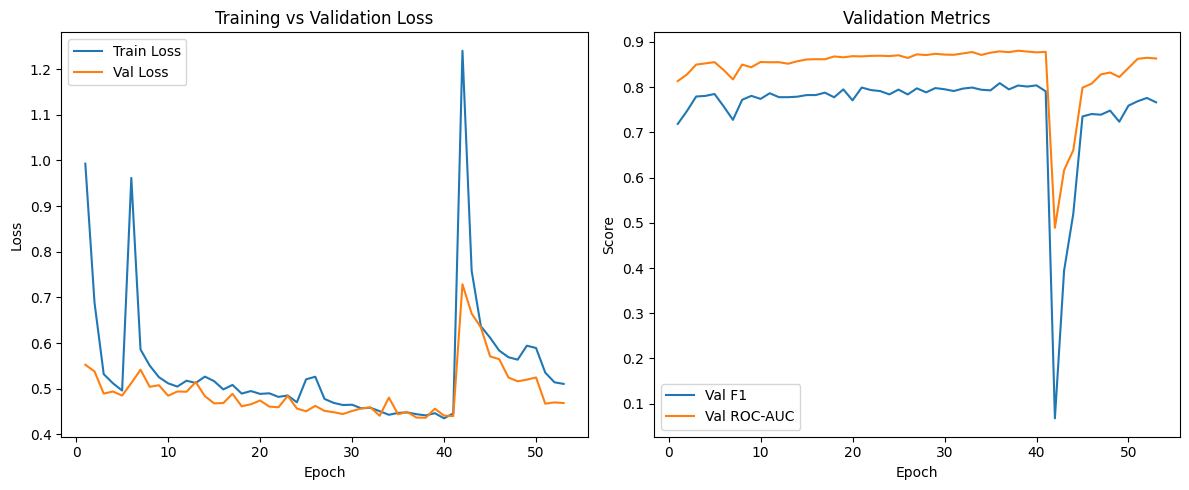

In [27]:
# training curves and validation metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

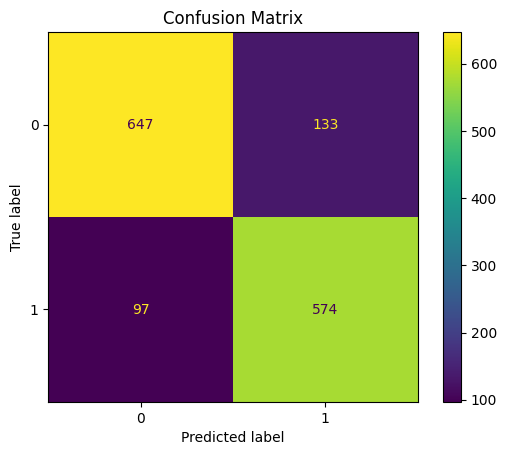

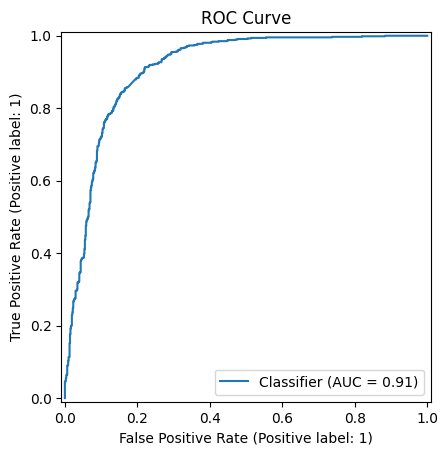

In [28]:
# confunsion matrix
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve")
plt.show()

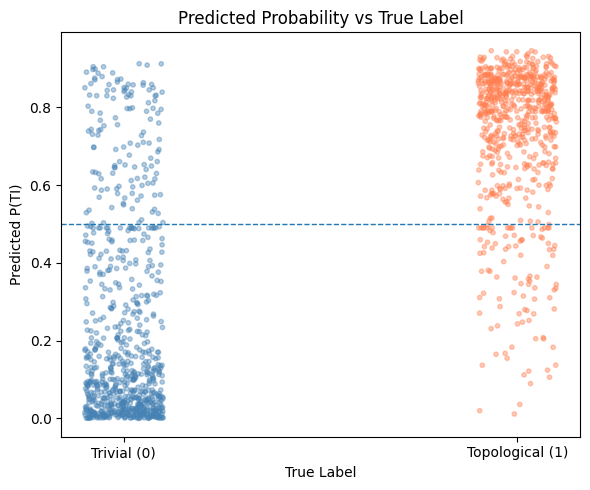

In [29]:
# scatter plot
plt.figure(figsize=(6, 5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels))

colors = ['steelblue' if l == 0 else 'coral' for l in labels]

plt.scatter(labels + jitter, probs, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xticks([0, 1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel('True Label')
plt.ylabel('Predicted P(TI)')
plt.title('Predicted Probability vs True Label')

plt.tight_layout()
plt.show()

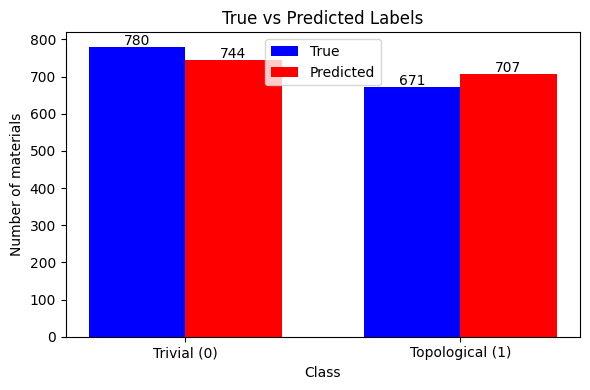

In [30]:
categories = ['Trivial (0)', 'Topological (1)']

true_counts = [(labels == 0).sum(), (labels == 1).sum()]
pred_counts = [(binary == 0).sum(), (binary == 1).sum()]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width/2, true_counts, width, label='True', color='blue')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted', color='red')

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center')

plt.xticks(x, categories)
plt.xlabel('Class')
plt.ylabel('Number of materials')
plt.title('True vs Predicted Labels')
plt.legend()

plt.tight_layout()
plt.show()

# GAT Model

In [31]:
class CharlesGAT(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=64, heads=4, dropout=0.2):
        super().__init__()

        # Node embedding
        self.node_emb = nn.Linear(node_dim, hidden_dim)

        # GAT layers
        self.gat1 = GATConv(
            hidden_dim,
            hidden_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout,
            concat=True
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            edge_dim=edge_dim,
            concat=False
        )

        # Global features
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)

        # Output
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data, return_attention=False):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u

        x = F.relu(self.node_emb(x))

        if return_attention:
            x, (edge_idx, attn) = self.gat1(
                x, edge_index, edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)

        x = F.elu(x)
        x = self.dropout(x)

        x = F.elu(self.gat2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = F.relu(self.global_emb(u))

        out = self.fc(torch.cat([x, u], dim=1))

        if return_attention:
            return out, edge_idx, attn

        return out

In [32]:
gat_model = CharlesGAT(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [33]:
train_losses_gat = []
val_losses_gat = []
val_f1_gat = []
val_roc_gat = []

def train_epoch_gat(loader):
    gat_model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = gat_model(data)
        loss = criterion(out, data.y.view(-1, 1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch_gat(loader):
    gat_model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = gat_model(data)
            loss = criterion(out, data.y.view(-1, 1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc
    best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch_gat(train_loader)
    val_loss, val_f1, val_roc = eval_epoch_gat(val_loader)

    scheduler.step(val_loss)

    train_losses_gat.append(train_loss)
    val_losses_gat.append(val_loss)
    val_f1_gat.append(val_f1)
    val_roc_gat.append(val_roc)

    print(f"[GAT] Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gat_model.state_dict(), "best_gat_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

[GAT] Epoch 001 | Train: 0.4891 | Val: 0.4346 | F1: 0.7821 | ROC: 0.8753
[GAT] Epoch 002 | Train: 0.4161 | Val: 0.4071 | F1: 0.8192 | ROC: 0.8900
[GAT] Epoch 003 | Train: 0.3864 | Val: 0.3916 | F1: 0.8225 | ROC: 0.9000
[GAT] Epoch 004 | Train: 0.3762 | Val: 0.4111 | F1: 0.8263 | ROC: 0.9049
[GAT] Epoch 005 | Train: 0.3595 | Val: 0.3772 | F1: 0.8417 | ROC: 0.9119
[GAT] Epoch 006 | Train: 0.3489 | Val: 0.3716 | F1: 0.8418 | ROC: 0.9154
[GAT] Epoch 007 | Train: 0.3408 | Val: 0.3559 | F1: 0.8504 | ROC: 0.9193
[GAT] Epoch 008 | Train: 0.3340 | Val: 0.3554 | F1: 0.8504 | ROC: 0.9206
[GAT] Epoch 009 | Train: 0.3298 | Val: 0.3510 | F1: 0.8532 | ROC: 0.9217
[GAT] Epoch 010 | Train: 0.3221 | Val: 0.3587 | F1: 0.8583 | ROC: 0.9195
[GAT] Epoch 011 | Train: 0.3166 | Val: 0.3504 | F1: 0.8585 | ROC: 0.9261
[GAT] Epoch 012 | Train: 0.3082 | Val: 0.3508 | F1: 0.8552 | ROC: 0.9230
[GAT] Epoch 013 | Train: 0.3053 | Val: 0.3464 | F1: 0.8587 | ROC: 0.9256
[GAT] Epoch 014 | Train: 0.3002 | Val: 0.3394 | F1:

In [34]:
gat_model.load_state_dict(torch.load("best_gat_model.pt"))

def evaluate_gat(loader):
    gat_model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = gat_model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print("\nGAT Test Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary


labels_gat, probs_gat, binary_gat = evaluate_gat(test_loader)


GAT Test Performance:
Accuracy : 0.8856
F1-score : 0.8809
ROC-AUC  : 0.9450
              precision    recall  f1-score   support

         0.0       0.92      0.86      0.89       780
         1.0       0.85      0.92      0.88       671

    accuracy                           0.89      1451
   macro avg       0.89      0.89      0.89      1451
weighted avg       0.89      0.89      0.89      1451



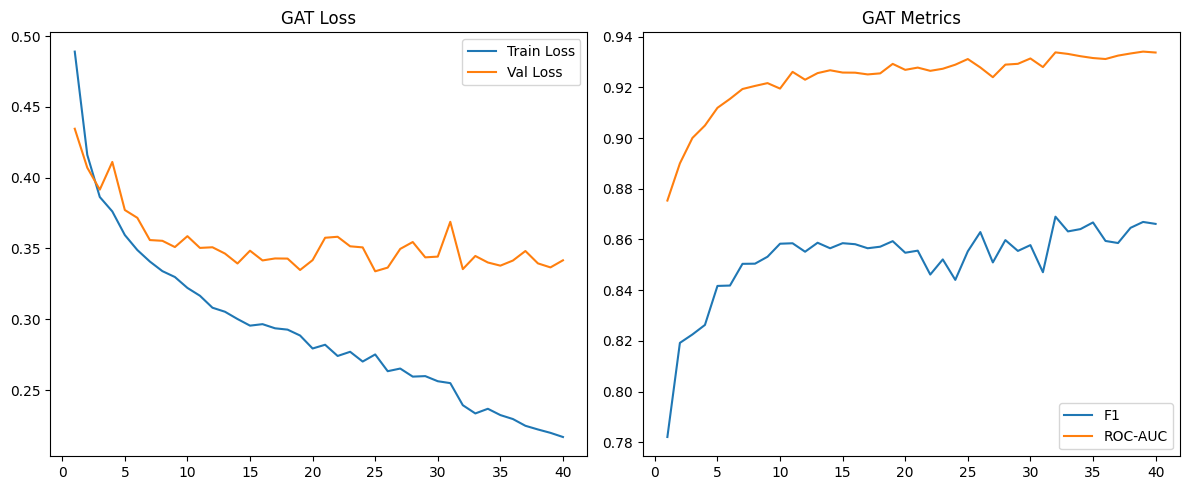

In [35]:
epochs_range = range(1, len(train_losses_gat) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_gat, label="Train Loss")
plt.plot(epochs_range, val_losses_gat, label="Val Loss")
plt.legend()
plt.title("GAT Loss")

# Metrics
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_gat, label="F1")
plt.plot(epochs_range, val_roc_gat, label="ROC-AUC")
plt.legend()
plt.title("GAT Metrics")

plt.tight_layout()
plt.show()

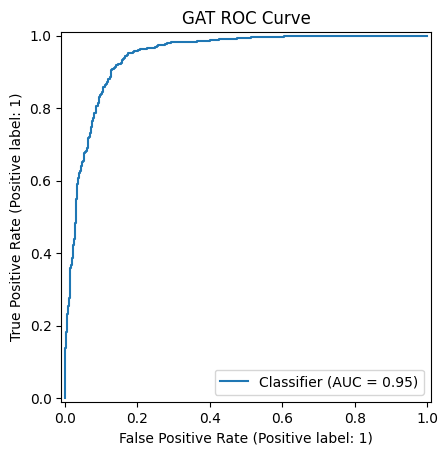

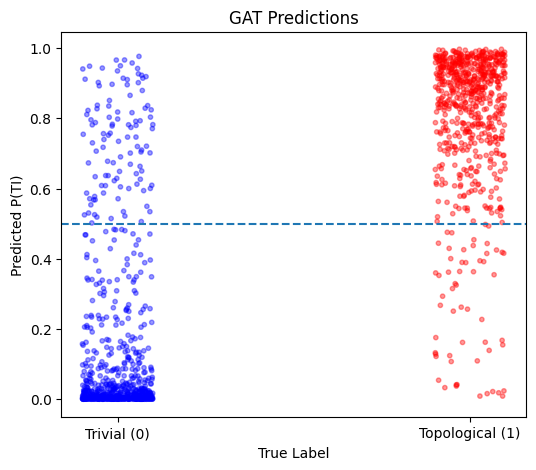

In [36]:
# ROC
RocCurveDisplay.from_predictions(labels_gat, probs_gat)
plt.title("GAT ROC Curve")
plt.show()

# Scatter
plt.figure(figsize=(6,5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels_gat))
colors = ['blue' if l == 0 else 'red' for l in labels_gat]

plt.scatter(labels_gat + jitter, probs_gat, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--')

plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel("True Label")
plt.ylabel("Predicted P(TI)")
plt.title("GAT Predictions")

plt.show()

# GAT Interpretability

In [37]:
# Get one batch
batch = next(iter(test_loader)).to(device)

# Pick ONE graph index (TI sample preferred)
graph_idx = (batch.y == 1).nonzero(as_tuple=True)[0][0].item()

# Node mask
node_mask = (batch.batch == graph_idx)

# Edge mask for edges only
edge_mask = node_mask[batch.edge_index[0]]

# Extract subgraph
x = batch.x[node_mask]
pos = batch.pos[node_mask]
edge_index = batch.edge_index[:, edge_mask]
edge_attr = batch.edge_attr[edge_mask]
u = batch.u[graph_idx:graph_idx+1]

# Re-index nodes
node_ids = node_mask.nonzero(as_tuple=True)[0]
mapping = {old.item(): i for i, old in enumerate(node_ids)}

edge_index = edge_index.clone()
for i in range(edge_index.shape[1]):
    edge_index[0, i] = mapping[edge_index[0, i].item()]
    edge_index[1, i] = mapping[edge_index[1, i].item()]

data_sample = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr,
    pos=pos,
    u=u
).to(device)
'''gat_model.eval()

# Pick one Topological sample (label = 1)
data_sample = None

for data in test_loader:
    data = data.to(device)
    for i in range(data.num_graphs):
        if data.y[i].item() == 1:
            mask = (data.batch == i)

            x_i = data.x[mask]
            pos_i = data.pos[mask]

            edge_mask = mask[data.edge_index[0]]
            edge_index_i = data.edge_index[:, edge_mask]

            # Re-index edges
            node_ids = mask.nonzero(as_tuple=True)[0]
            edge_index_i = edge_index_i - node_ids[0]

            edge_attr_i = data.edge_attr[edge_mask]
            u_i = data.u[i:i+1]
            y_i = data.y[i:i+1]

            data_sample = Data(
                x=x_i,
                edge_index=edge_index_i,
                edge_attr=edge_attr_i,
                u=u_i,
                y=y_i,
                pos=pos_i
            ).to(device)

            break
    if data_sample is not None:
        break

# fallback
if data_sample is None:
    print("No TI sample found, using first sample")
    data_sample = next(iter(test_loader)).to(device)'''

In [38]:
# Extract attention weights
gat_model.eval()

with torch.no_grad():
    _, ei, attn = gat_model(data_sample, return_attention=True)

# Average heads
attn = attn.mean(dim=1).cpu().numpy()
edge_index = ei.cpu().numpy()
'''with torch.no_grad():
    _, edge_index, attn = gat_model(data_sample, return_attention=True)

# Average over heads
attn = attn.mean(dim=1).cpu().numpy()
edge_index = edge_index.cpu().numpy()'''

In [39]:
# convert node to edge importance
num_nodes = data_sample.num_nodes
node_attn = np.zeros(num_nodes)

# Only incoming attention
for i, (_, dst) in enumerate(edge_index.T):
    node_attn[dst] += attn[i]

# Normalize
node_attn = (node_attn - node_attn.min()) / (node_attn.max() - node_attn.min() + 1e-8)

# If scaled:
node_features_raw = node_scaler.inverse_transform(data_sample.x.cpu().numpy())
Z = node_features_raw[:, 0]

# If NOT scaled:
# Z = data_sample.x[:, 0].cpu().numpy()
'''num_nodes = data_sample.num_nodes

node_attn = np.zeros(num_nodes)
node_degree = np.zeros(num_nodes)

for i, (src, dst) in enumerate(edge_index.T):
    node_attn[src] += attn[i]
    node_attn[dst] += attn[i]

    node_degree[src] += 1
    node_degree[dst] += 1

# Mean attention per node
node_attn = node_attn / (node_degree + 1e-8)

# Normalize [0,1]
node_attn = (node_attn - node_attn.min()) / (
    node_attn.max() - node_attn.min() + 1e-8'''
)

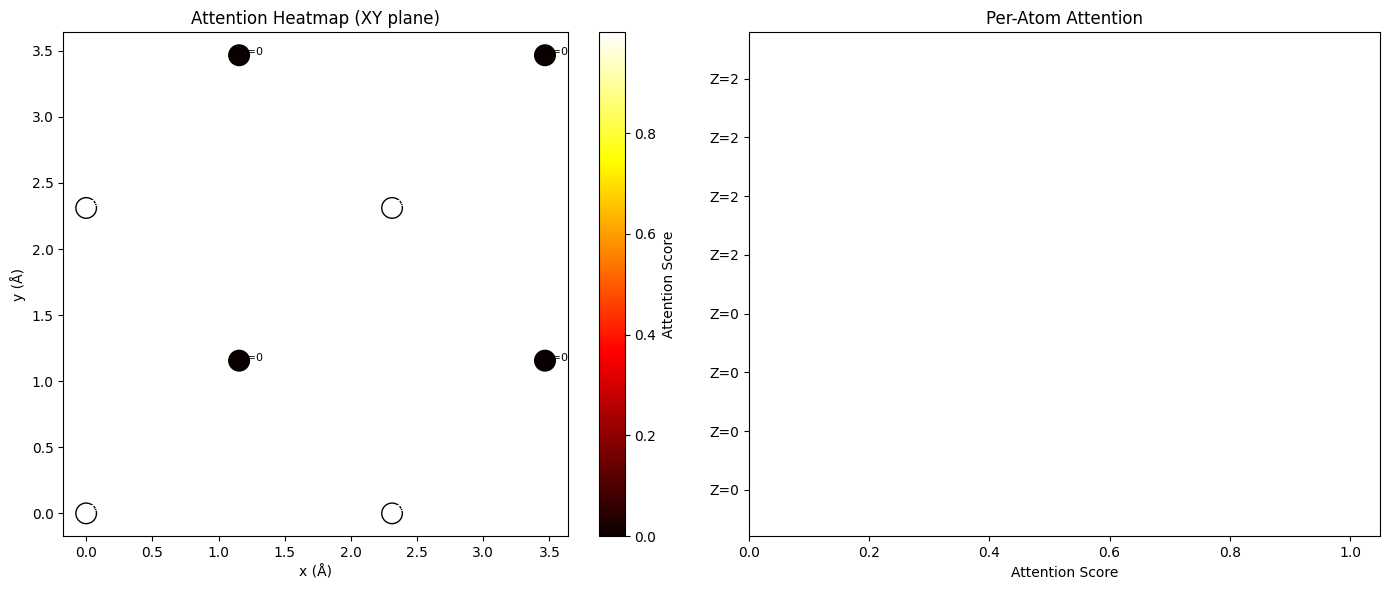

In [40]:
# Visualization
coords = data_sample.pos.cpu().numpy()

plt.figure(figsize=(6,6))

sc = plt.scatter(
    coords[:,0], coords[:,1],
    c=node_attn,
    cmap='hot',
    s=200,
    edgecolors='black'
)

plt.colorbar(sc, label="Attention Score")

# Labels
for i, (x_, y_, z_) in enumerate(zip(coords[:,0], coords[:,1], Z)):
    plt.text(x_, y_, f"Z={int(z_)}", fontsize=8)

plt.title("Attention Heatmap (XY plane)")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")

plt.tight_layout()
plt.show()
'''import matplotlib.pyplot as plt

coords = data_sample.pos.cpu().numpy()
Z = data_sample.x[:, 0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Spatial heatmap --------
sc = axes[0].scatter(
    coords[:, 0],
    coords[:, 1],
    c=node_attn,
    cmap='hot',
    s=220,
    edgecolors='black'
)

plt.colorbar(sc, ax=axes[0], label='Attention Score')

# Label atoms
for i in range(len(Z)):
    axes[0].annotate(
        f'Z={int(Z[i])}',
        (coords[i, 0], coords[i, 1]),
        fontsize=8,
        color='white' if node_attn[i] > 0.6 else 'black'
    )

axes[0].set_title("Attention Heatmap (XY plane)")
axes[0].set_xlabel("x (Å)")
axes[0].set_ylabel("y (Å)")

# RIGHT: Bar chart
axes[1].barh(
    range(len(node_attn)),
    node_attn,
    color=plt.cm.hot(node_attn)
)

axes[1].set_yticks(range(len(Z)))
axes[1].set_yticklabels([f"Z={int(z)}" for z in Z])
axes[1].set_xlabel("Attention Score")
axes[1].set_title("Per-Atom Attention")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()'''

In [ ]:
# attention per atom
order = np.argsort(node_attn)[::-1]

plt.figure(figsize=(6,4))

plt.barh(
    range(num_nodes),
    node_attn[order],
    color=plt.cm.hot(node_attn[order])
)

plt.yticks(range(num_nodes), [f"Z={int(Z[i])}" for i in order])
plt.gca().invert_yaxis()

plt.xlabel("Attention Score")
plt.title("Per-Atom Attention (Sorted)")

plt.tight_layout()
plt.show()

In [ ]:
# Edge heatmap

plt.figure(figsize=(10,2))

sns.heatmap(
    attn.reshape(1, -1),
    cmap="viridis",
    cbar=True
)

plt.title("Edge Attention Weights")
plt.xlabel("Edge Index")
plt.yticks([])

plt.tight_layout()
plt.show()

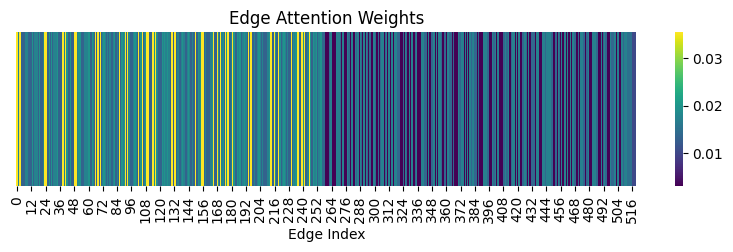

In [41]:
# Edge importance

plt.figure(figsize=(10, 2))

sns.heatmap(
    attn.reshape(1, -1),
    cmap="viridis",
    cbar=True
)

plt.title("Edge Attention Weights")
plt.xlabel("Edge Index")
plt.yticks([])
plt.show()

In [42]:
# Most important bonds
threshold = np.percentile(attn, 90)

print("\nTop important bonds:\n")

for i, (src, dst) in enumerate(edge_index.T):
    if attn[i] > threshold:
        print(
            f"Edge {i}: Atom {src} (Z={int(Z[src])}) ↔ "
            f"Atom {dst} (Z={int(Z[dst])}) | "
            f"Weight={attn[i]:.3f}"
        )
'''print("\nTop important bonds:\n")

threshold = np.percentile(attn, 90)

for i, (src, dst) in enumerate(edge_index.T):
    if attn[i] > threshold:
        print(
            f"Edge {i}: Atom {src} (Z={int(Z[src])}) "
            f"Atom {dst} (Z={int(Z[dst])}) "
            f"Weight={attn[i]:.3f}"
        )'''


Top important bonds:

Edge 0: Atom 0 (Z=2) Atom 7 (Z=0) Weight=0.035
Edge 2: Atom 0 (Z=2) Atom 5 (Z=0) Weight=0.035
Edge 3: Atom 0 (Z=2) Atom 4 (Z=0) Weight=0.035
Edge 23: Atom 0 (Z=2) Atom 6 (Z=0) Weight=0.035
Edge 24: Atom 0 (Z=2) Atom 5 (Z=0) Weight=0.035
Edge 25: Atom 0 (Z=2) Atom 4 (Z=0) Weight=0.035
Edge 38: Atom 0 (Z=2) Atom 7 (Z=0) Weight=0.035
Edge 39: Atom 0 (Z=2) Atom 6 (Z=0) Weight=0.035
Edge 41: Atom 0 (Z=2) Atom 4 (Z=0) Weight=0.035
Edge 48: Atom 0 (Z=2) Atom 7 (Z=0) Weight=0.035
Edge 49: Atom 0 (Z=2) Atom 6 (Z=0) Weight=0.035
Edge 50: Atom 0 (Z=2) Atom 5 (Z=0) Weight=0.035
Edge 66: Atom 1 (Z=2) Atom 5 (Z=0) Weight=0.035
Edge 68: Atom 1 (Z=2) Atom 7 (Z=0) Weight=0.035
Edge 70: Atom 1 (Z=2) Atom 6 (Z=0) Weight=0.035
Edge 86: Atom 1 (Z=2) Atom 4 (Z=0) Weight=0.035
Edge 91: Atom 1 (Z=2) Atom 7 (Z=0) Weight=0.035
Edge 93: Atom 1 (Z=2) Atom 6 (Z=0) Weight=0.035
Edge 102: Atom 1 (Z=2) Atom 4 (Z=0) Weight=0.035
Edge 105: Atom 1 (Z=2) Atom 5 (Z=0) Weight=0.035
Edge 109: Atom 1 (

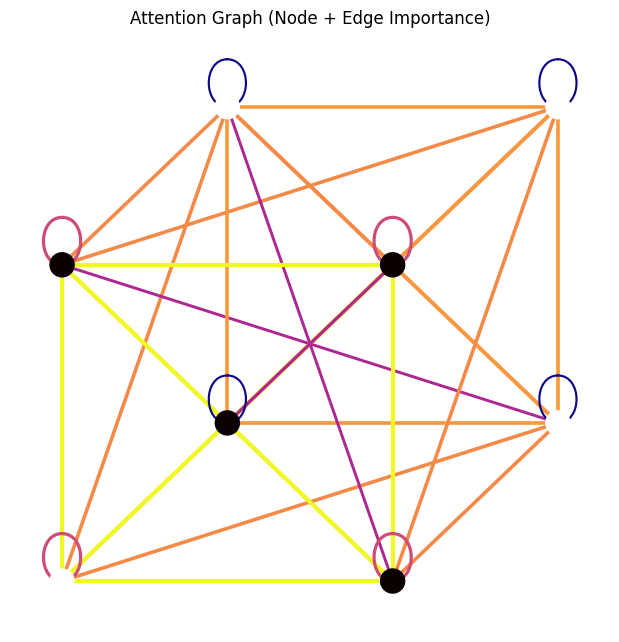

In [43]:
import networkx as nx

G = nx.Graph()

# Add edges with weights
for i, (u, v) in enumerate(edge_index.T):
    G.add_edge(u, v, weight=attn[i])

coords = data_sample.pos.cpu().numpy()
pos = {i: coords[i][:2] for i in range(len(coords))}

# Normalize edge weights for width
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths = [3 * (w / max(edge_weights)) for w in edge_weights]

plt.figure(figsize=(6,6))

nx.draw(
    G,
    pos,
    node_color=node_attn,
    cmap=plt.cm.hot,
    node_size=300,
    edge_color=edge_weights,
    edge_cmap=plt.cm.plasma,
    width=edge_widths
)

plt.title("Attention Graph (Node + Edge Importance)")
plt.show()

In [48]:
gat_model.eval()

with torch.no_grad():
    out, edge_index, attn = gat_model(data_sample, return_attention=True)

attn = attn.mean(dim=1).cpu().numpy()   # average heads
edge_index = edge_index.cpu().numpy()

In [49]:
num_nodes = data_sample.num_nodes
node_importance = np.zeros(num_nodes)

for i, (src, dst) in enumerate(edge_index.T):
    node_importance[dst] += attn[i]   # ONLY incoming

In [51]:
node_importance = node_importance / (node_importance.sum() + 1e-8)

node_importance = (node_importance - node_importance.min()) / (
    node_importance.max() - node_importance.min() + 1e-8
)

In [52]:
threshold = np.percentile(attn, 90)   # top 10% only

important_edges = [
    (u, v, attn[i])
    for i, (u, v) in enumerate(edge_index.T)
    if attn[i] > threshold
]

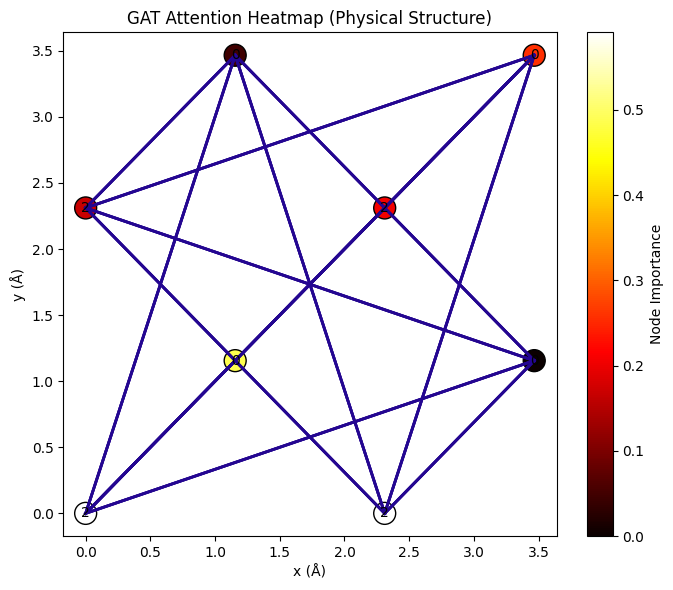

In [53]:
coords = data_sample.pos.cpu().numpy()
Z_vals = data_sample.x[:, 0].cpu().numpy()

plt.figure(figsize=(7,6))

# nodes
sc = plt.scatter(
    coords[:,0], coords[:,1],
    c=node_importance,
    cmap='hot',
    s=250,
    edgecolors='black'
)

# edges
for u, v, w in important_edges:
    x = [coords[u,0], coords[v,0]]
    y = [coords[u,1], coords[v,1]]
    plt.plot(x, y, color=plt.cm.plasma(w), linewidth=2)

# labels
for i in range(num_nodes):
    plt.text(coords[i,0], coords[i,1], f"{int(Z_vals[i])}",
             ha='center', va='center',
             color='white' if node_importance[i] > 0.6 else 'black')

plt.colorbar(sc, label="Node Importance")

plt.title("GAT Attention Heatmap (Physical Structure)")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")

plt.tight_layout()
plt.show()

# Python Symbolic Regression

In [44]:
# Data for pysr
# Use your collected global features

X_train = global_samples
y_train = train_df['label'].values

# Apply scaling
X_train = global_scaler.transform(X_train)

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (6767, 14)
y shape: (6767,)


In [45]:
# Features

feature_names = [f"x{i}" for i in range(X_train.shape[1])]

print("Features:", feature_names)

Features: ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13']


In [46]:
# PySR model
model_sr = PySRRegressor(
    niterations=80,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=["sqrt", "log", "exp", "abs"],
    model_selection="best",
    verbosity=1
)
variable_names=feature_names
model_sr.fit(X_train, y_train)

print("\nAll Discovered Equations:\n")
print(model_sr)

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 3.350e+03
Progress: 18 / 2480 total iterations (0.726%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.486e-01  0.000e+00  y = 0.46238
10          2.353e-01  6.080e-03  y = sqrt(((0.39534 ^ x₁₁) - -0.31172) * (0.063324 ^ 0.7239...
                                      ))
11          1.827e-01  2.534e-01  y = abs(log((1.0834 ^ ((x₁₂ - x₁₀) / 0.30841)) - -0.38958)...
                                      )
12          1.714e-01  6.375e-02  y = abs(log(abs((1.0834 ^ ((x₁₂ - x₁₀) / 0.30841)) - -0.51...
                                      731)))
13          1.705e-01  5.223e-03  y = log(abs((1.0791 ^ ((x₁₂ - x₁₀) / 0.34207)) - -0.33649)...
                                      ) - -0.14944
14          1.607e-01  5.908e-02  y = abs(log(abs((1.2199 

[ Info: Final population:
[ Info: Results saved to:



All Discovered Equations:

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.46235013   
	1   >>>>  0.152117                              exp(-1.0706764 - x10)   
	2         0.087787                      0.12174595 / (x10 + 0.906674)   
	3         0.016203               sqrt(0.01850496 / (x10 + 0.7824166))   
	4         0.000059  sqrt(-0.028702827 / ((x10 * -1.6581101) + -1.2...   
	5         0.002999  (-0.013894603 / ((x10 * -1.7880355) + -1.37231...   
	6         0.012328  sqrt((-0.018130582 / ((x10 * -1.8311198) + -1....   
	7         0.003065  sqrt((-0.018130582 / ((x10 * -1.8311198) + -1....   
	8         0.000023  sqrt((-0.01938858 / ((x10 * -1.8313518) + -1.4...   
	9         0.000716  abs(sqrt(exp((-0.71660054 - abs(((x13 - 0.4022...   
	10        0.001208  abs(sqrt(sqrt(exp((x10 - -0.7575947) * (-1.365...   
	11        0.001344  abs(sqrt(sqrt(exp((-1.3652751 - ab

In [47]:
best_eq = model_sr.get_best()

print("\nBest Equation:")
print(best_eq)


Best Equation:
complexity                                            4
loss                                           0.157501
equation                          exp(-1.0706764 - x10)
score                                          0.152117
sympy_format                      exp(-x10 - 1.0706764)
lambda_format    PySRFunction(X=>exp(-x10 - 1.0706764))
Name: 1, dtype: object
